# Exp1 vs Exp3 — Neuron Comparison
Direct visual comparison of reward-sensitive neurons (Exp1) vs anhedonia-changed neurons (Exp3).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size']  = 11

N_LAYERS  = 28
N_NEURONS = 18944

In [2]:
# ── Load Exp1 CSVs ────────────────────────────────────────────────────────────
df_core   = pd.read_csv('/mnt/upschrimpf2/scratch/mahdipou/models/Anhedonic-AI/Experiment1/phase4/extraction/master_incentive_core.csv')
df_money  = pd.read_csv('/mnt/upschrimpf2/scratch/mahdipou/models/Anhedonic-AI/Experiment1/phase4/extraction/universal_money_neurons.csv')
df_reward = pd.read_csv('/mnt/upschrimpf2/scratch/mahdipou/models/Anhedonic-AI/Experiment1/phase4/extraction/universal_reward_neurons.csv')

set_core   = set(zip(df_core['layer'],   df_core['neuron']))
set_money  = set(zip(df_money['layer'],  df_money['neuron']))
set_reward = set(zip(df_reward['layer'], df_reward['neuron']))

# ── Load Exp3 activations ─────────────────────────────────────────────────────
neu_normal    = np.load('activations/activations_neurons_normal.npy')    # (100,28,18944)
neu_anhedonic = np.load('activations/activations_neurons_anhedonic.npy')

diff_signed = neu_anhedonic.mean(axis=0) - neu_normal.mean(axis=0)      # (28,18944)
diff_abs    = np.abs(diff_signed)

pooled_std  = np.sqrt((neu_normal.std(axis=0)**2 + neu_anhedonic.std(axis=0)**2) / 2 + 1e-8)
effect_size = diff_signed / pooled_std

# Exp3 top-500 changed neurons
flat_idx   = np.argsort(diff_abs.flatten())[::-1][:500]
exp3_layers = flat_idx // N_NEURONS
exp3_neurs  = flat_idx %  N_NEURONS
exp3_deltas = diff_signed[exp3_layers, exp3_neurs]
set_exp3    = set(zip(exp3_layers, exp3_neurs))
set_exp3_up   = {(l,n) for l,n in set_exp3 if diff_signed[l,n] > 0}
set_exp3_down = {(l,n) for l,n in set_exp3 if diff_signed[l,n] < 0}

print('Loaded.')
print(f'Exp1 core: {len(set_core)} | money: {len(set_money)} | reward: {len(set_reward)}')
print(f'Exp3 top-500: {len(set_exp3_up)} UP, {len(set_exp3_down)} DOWN')

Loaded.
Exp1 core: 3528 | money: 5467 | reward: 5558
Exp3 top-500: 207 UP, 293 DOWN


## Plot 1 — Layer Distribution: Exp1 vs Exp3 Side by Side

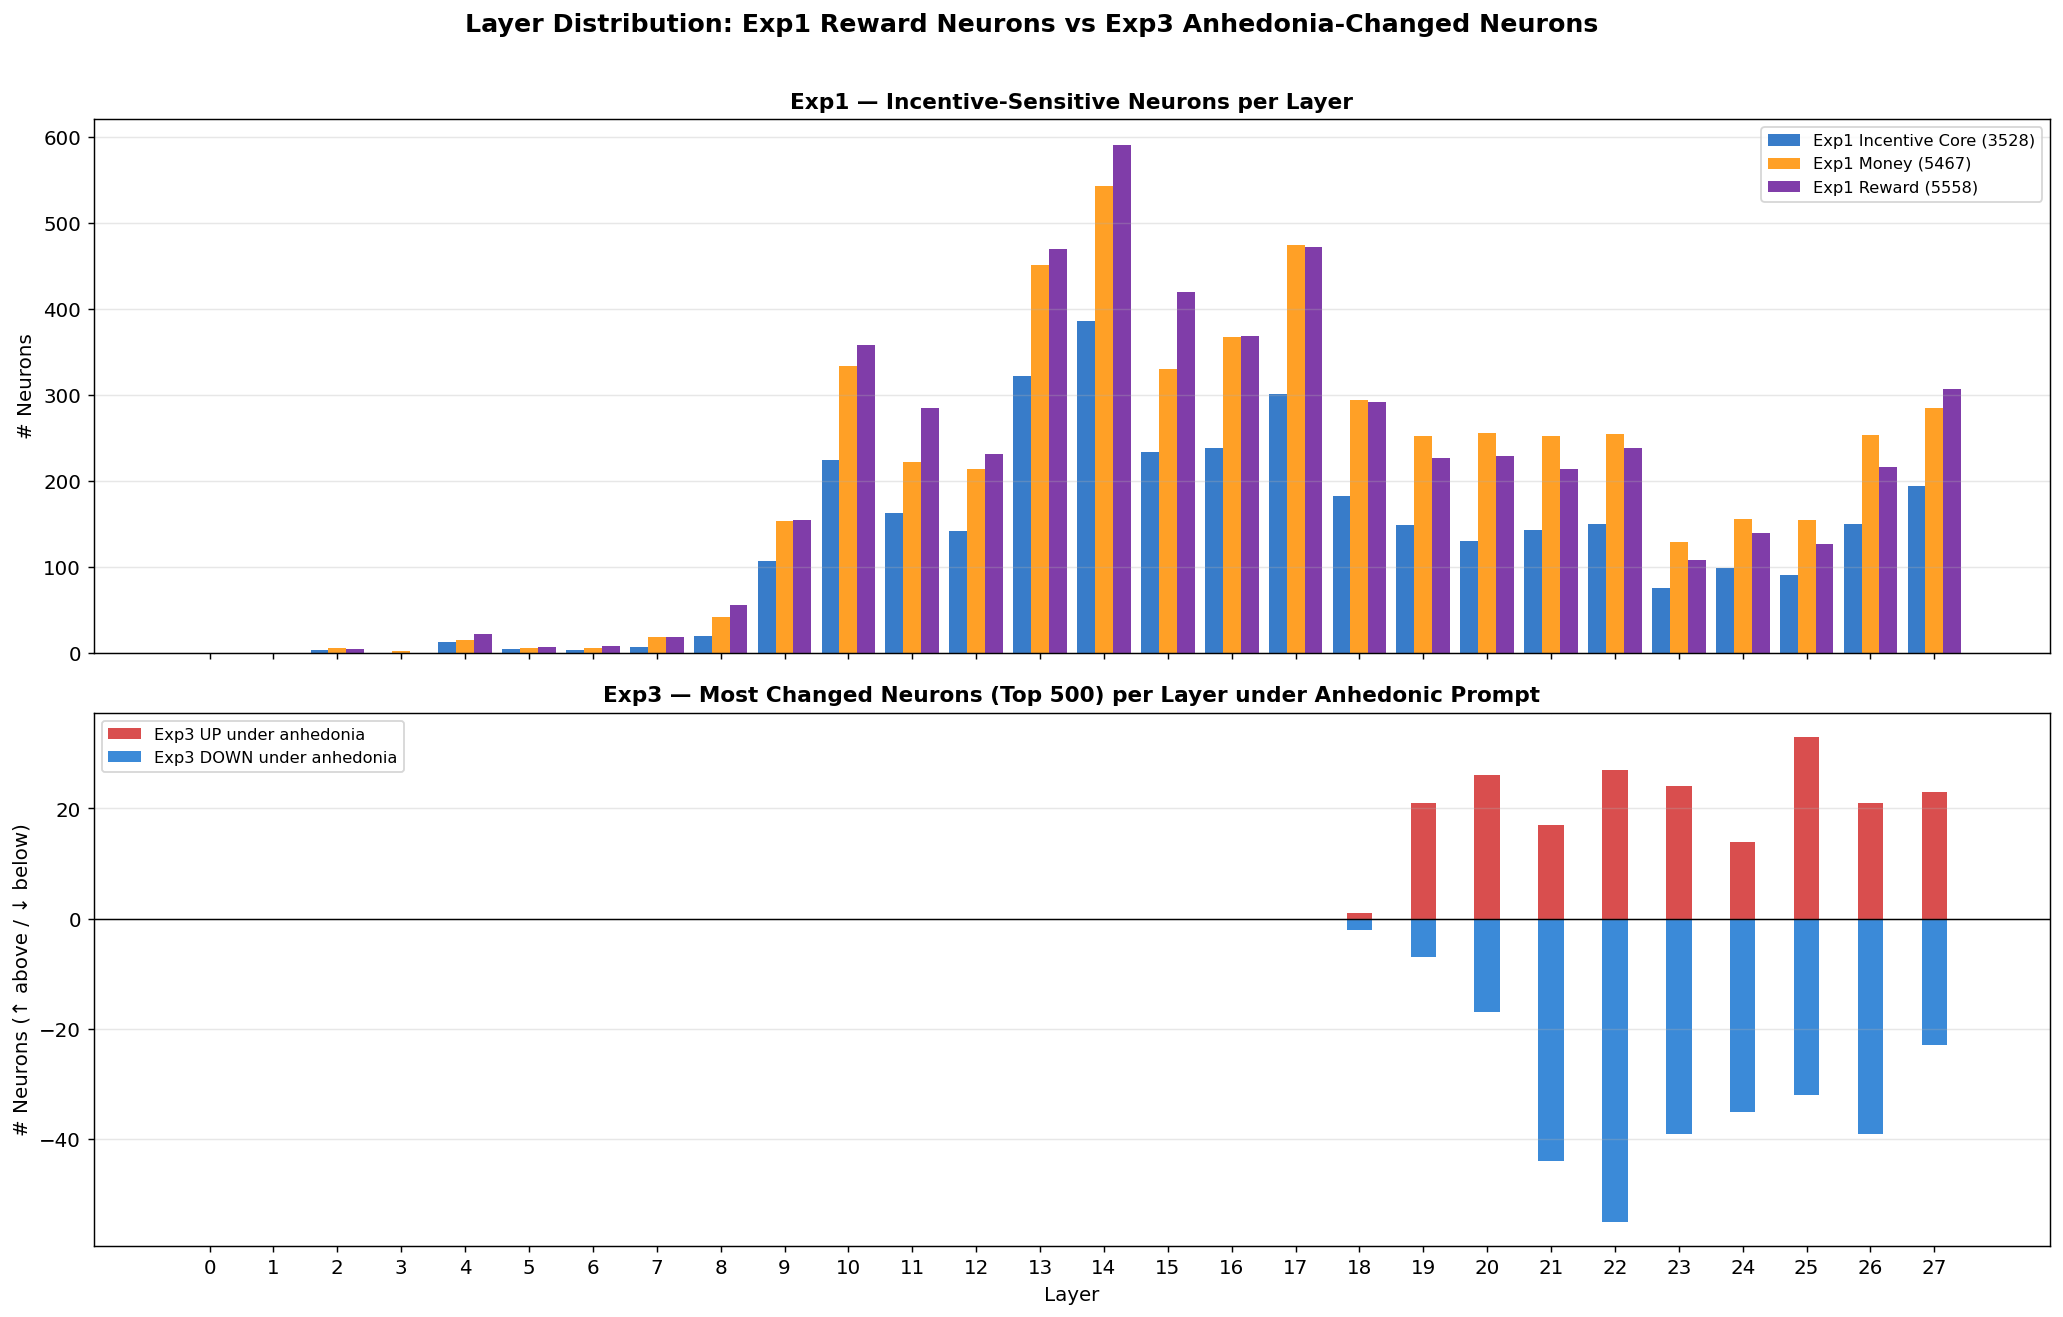

In [3]:
# Count neurons per layer for each set
def count_per_layer(neuron_set, n_layers=28):
    counts = np.zeros(n_layers, dtype=int)
    for l, n in neuron_set:
        counts[l] += 1
    return counts

layers = np.arange(N_LAYERS)

core_per_layer   = count_per_layer(set_core)
money_per_layer  = count_per_layer(set_money)
reward_per_layer = count_per_layer(set_reward)
exp3_up_per_layer   = count_per_layer(set_exp3_up)
exp3_down_per_layer = count_per_layer(set_exp3_down)

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# ── TOP: Exp1 neuron counts per layer ──
ax = axes[0]
w = 0.28
ax.bar(layers - w,   core_per_layer,   w, label=f'Exp1 Incentive Core ({len(set_core)})',   color='#1565C0', alpha=0.85)
ax.bar(layers,       money_per_layer,  w, label=f'Exp1 Money ({len(set_money)})',           color='#FF8F00', alpha=0.85)
ax.bar(layers + w,   reward_per_layer, w, label=f'Exp1 Reward ({len(set_reward)})',         color='#6A1B9A', alpha=0.85)
ax.set_ylabel('# Neurons')
ax.set_title('Exp1 — Incentive-Sensitive Neurons per Layer', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(layers)

# ── BOTTOM: Exp3 anhedonia-changed neurons per layer ──
ax = axes[1]
ax.bar(layers,  exp3_up_per_layer,    0.4, label='Exp3 UP under anhedonia',   color='#D32F2F', alpha=0.85)
ax.bar(layers, -exp3_down_per_layer,  0.4, label='Exp3 DOWN under anhedonia', color='#1976D2', alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('# Neurons (↑ above / ↓ below)')
ax.set_xlabel('Layer')
ax.set_title('Exp3 — Most Changed Neurons (Top 500) per Layer under Anhedonic Prompt', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(layers)

plt.suptitle('Layer Distribution: Exp1 Reward Neurons vs Exp3 Anhedonia-Changed Neurons',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_layer_distribution_comparison.png', bbox_inches='tight')
plt.show()

## Plot 2 — Scatter: Every Neuron as a Point (Layer vs Neuron Index)

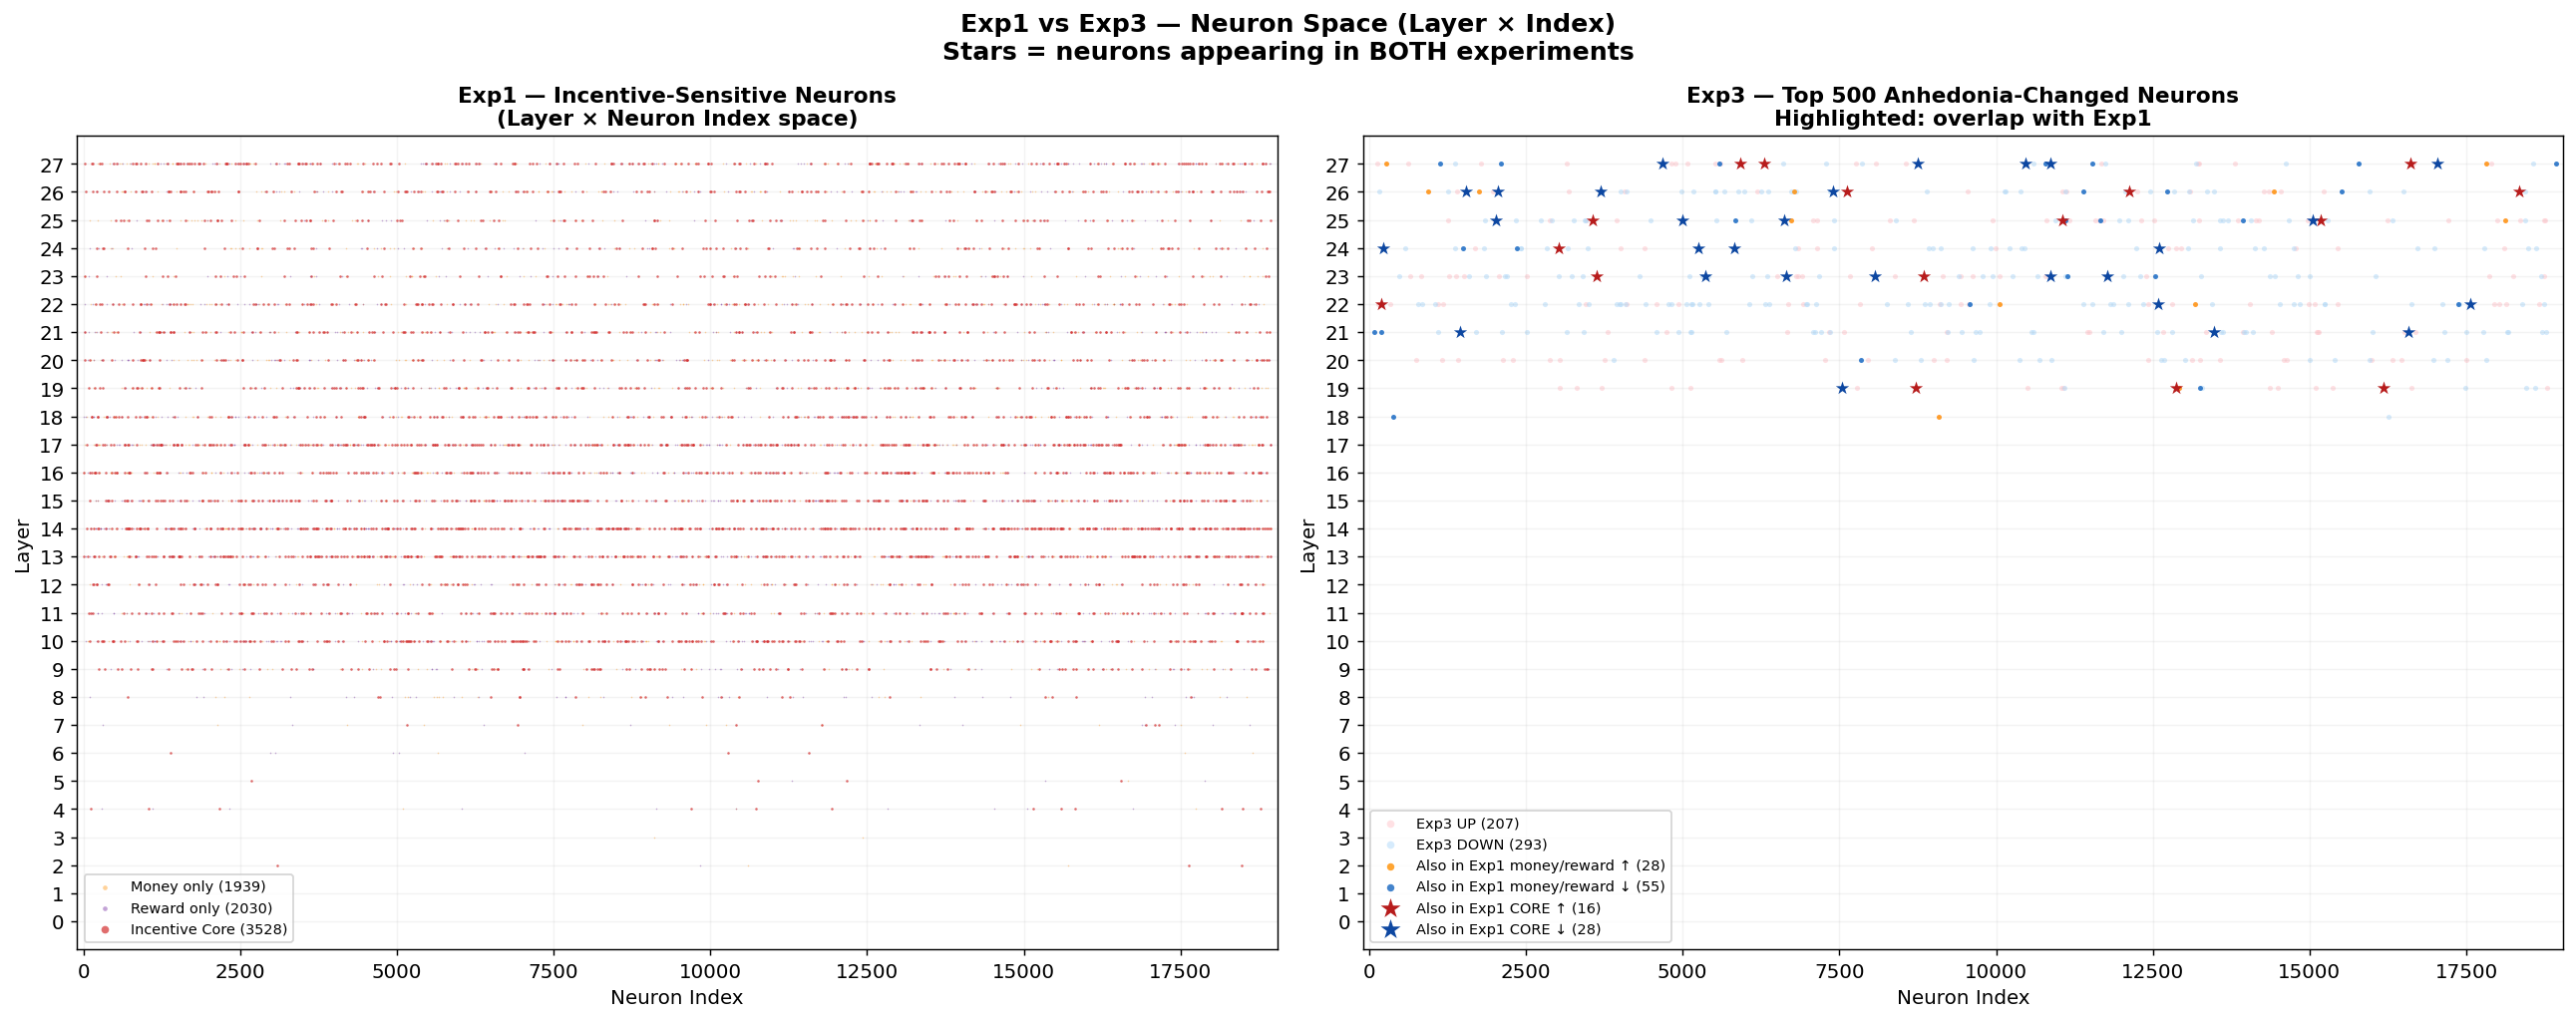

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# ── LEFT: Exp1 neurons ──
ax = axes[0]
# Plot each Exp1 set as a different color/marker
# Core = blue dots, money-only = orange, reward-only = purple, money+reward = green
money_only  = set_money  - set_core - set_reward
reward_only = set_reward - set_core - set_money
money_and_reward = (set_money & set_reward) - set_core

def scatter_set(ax, neuron_set, color, label, marker='.', size=4, alpha=0.5, zorder=1):
    if not neuron_set: return
    ls, ns = zip(*neuron_set)
    ax.scatter(ns, ls, c=color, s=size, alpha=alpha, marker=marker,
               label=label, zorder=zorder, linewidths=0)

scatter_set(ax, money_only,       '#FF8F00', f'Money only ({len(money_only)})',           size=3,  alpha=0.4)
scatter_set(ax, reward_only,      '#6A1B9A', f'Reward only ({len(reward_only)})',         size=3,  alpha=0.4)
scatter_set(ax, money_and_reward, '#2E7D32', f'Money+Reward ({len(money_and_reward)})',   size=5,  alpha=0.6)
scatter_set(ax, set_core,         '#D32F2F', f'Incentive Core ({len(set_core)})',         size=8,  alpha=0.7, zorder=3)

ax.set_xlabel('Neuron Index', fontsize=11)
ax.set_ylabel('Layer', fontsize=11)
ax.set_yticks(range(N_LAYERS))
ax.set_title('Exp1 — Incentive-Sensitive Neurons\n(Layer × Neuron Index space)', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, markerscale=3)
ax.set_xlim(-100, N_NEURONS + 100)
ax.set_ylim(-1, N_LAYERS)
ax.grid(alpha=0.15)

# ── RIGHT: Exp3 neurons ──
ax = axes[1]
# Background: all top-500 Exp3 neurons
exp3_up_l,   exp3_up_n   = zip(*set_exp3_up)   if set_exp3_up   else ([], [])
exp3_down_l, exp3_down_n = zip(*set_exp3_down) if set_exp3_down else ([], [])
ax.scatter(exp3_up_n,   exp3_up_l,   c='#FFCDD2', s=8,  alpha=0.6, label=f'Exp3 UP ({len(set_exp3_up)})',   linewidths=0)
ax.scatter(exp3_down_n, exp3_down_l, c='#BBDEFB', s=8,  alpha=0.6, label=f'Exp3 DOWN ({len(set_exp3_down)})', linewidths=0)

# Overlay: neurons in BOTH Exp3 AND Exp1 core
overlap_up_core   = set_exp3_up   & set_core
overlap_down_core = set_exp3_down & set_core
overlap_up_any    = set_exp3_up   & (set_money | set_reward)
overlap_down_any  = set_exp3_down & (set_money | set_reward)

scatter_set(ax, overlap_up_any,    '#FF8F00', f'Also in Exp1 money/reward ↑ ({len(overlap_up_any)})',   size=30, alpha=0.8, zorder=3)
scatter_set(ax, overlap_down_any,  '#1565C0', f'Also in Exp1 money/reward ↓ ({len(overlap_down_any)})', size=30, alpha=0.8, zorder=3)
scatter_set(ax, overlap_up_core,   '#B71C1C', f'Also in Exp1 CORE ↑ ({len(overlap_up_core)})',          size=60, alpha=1.0, zorder=4, marker='*')
scatter_set(ax, overlap_down_core, '#0D47A1', f'Also in Exp1 CORE ↓ ({len(overlap_down_core)})',        size=60, alpha=1.0, zorder=4, marker='*')

ax.set_xlabel('Neuron Index', fontsize=11)
ax.set_ylabel('Layer', fontsize=11)
ax.set_yticks(range(N_LAYERS))
ax.set_title('Exp3 — Top 500 Anhedonia-Changed Neurons\nHighlighted: overlap with Exp1', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, markerscale=1.5)
ax.set_xlim(-100, N_NEURONS + 100)
ax.set_ylim(-1, N_LAYERS)
ax.grid(alpha=0.15)

plt.suptitle('Exp1 vs Exp3 — Neuron Space (Layer × Index)\nStars = neurons appearing in BOTH experiments',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_scatter_layer_neuron.png', bbox_inches='tight')
plt.show()

## Plot 3 — Exact Shared Neurons: Zoomed Layer View

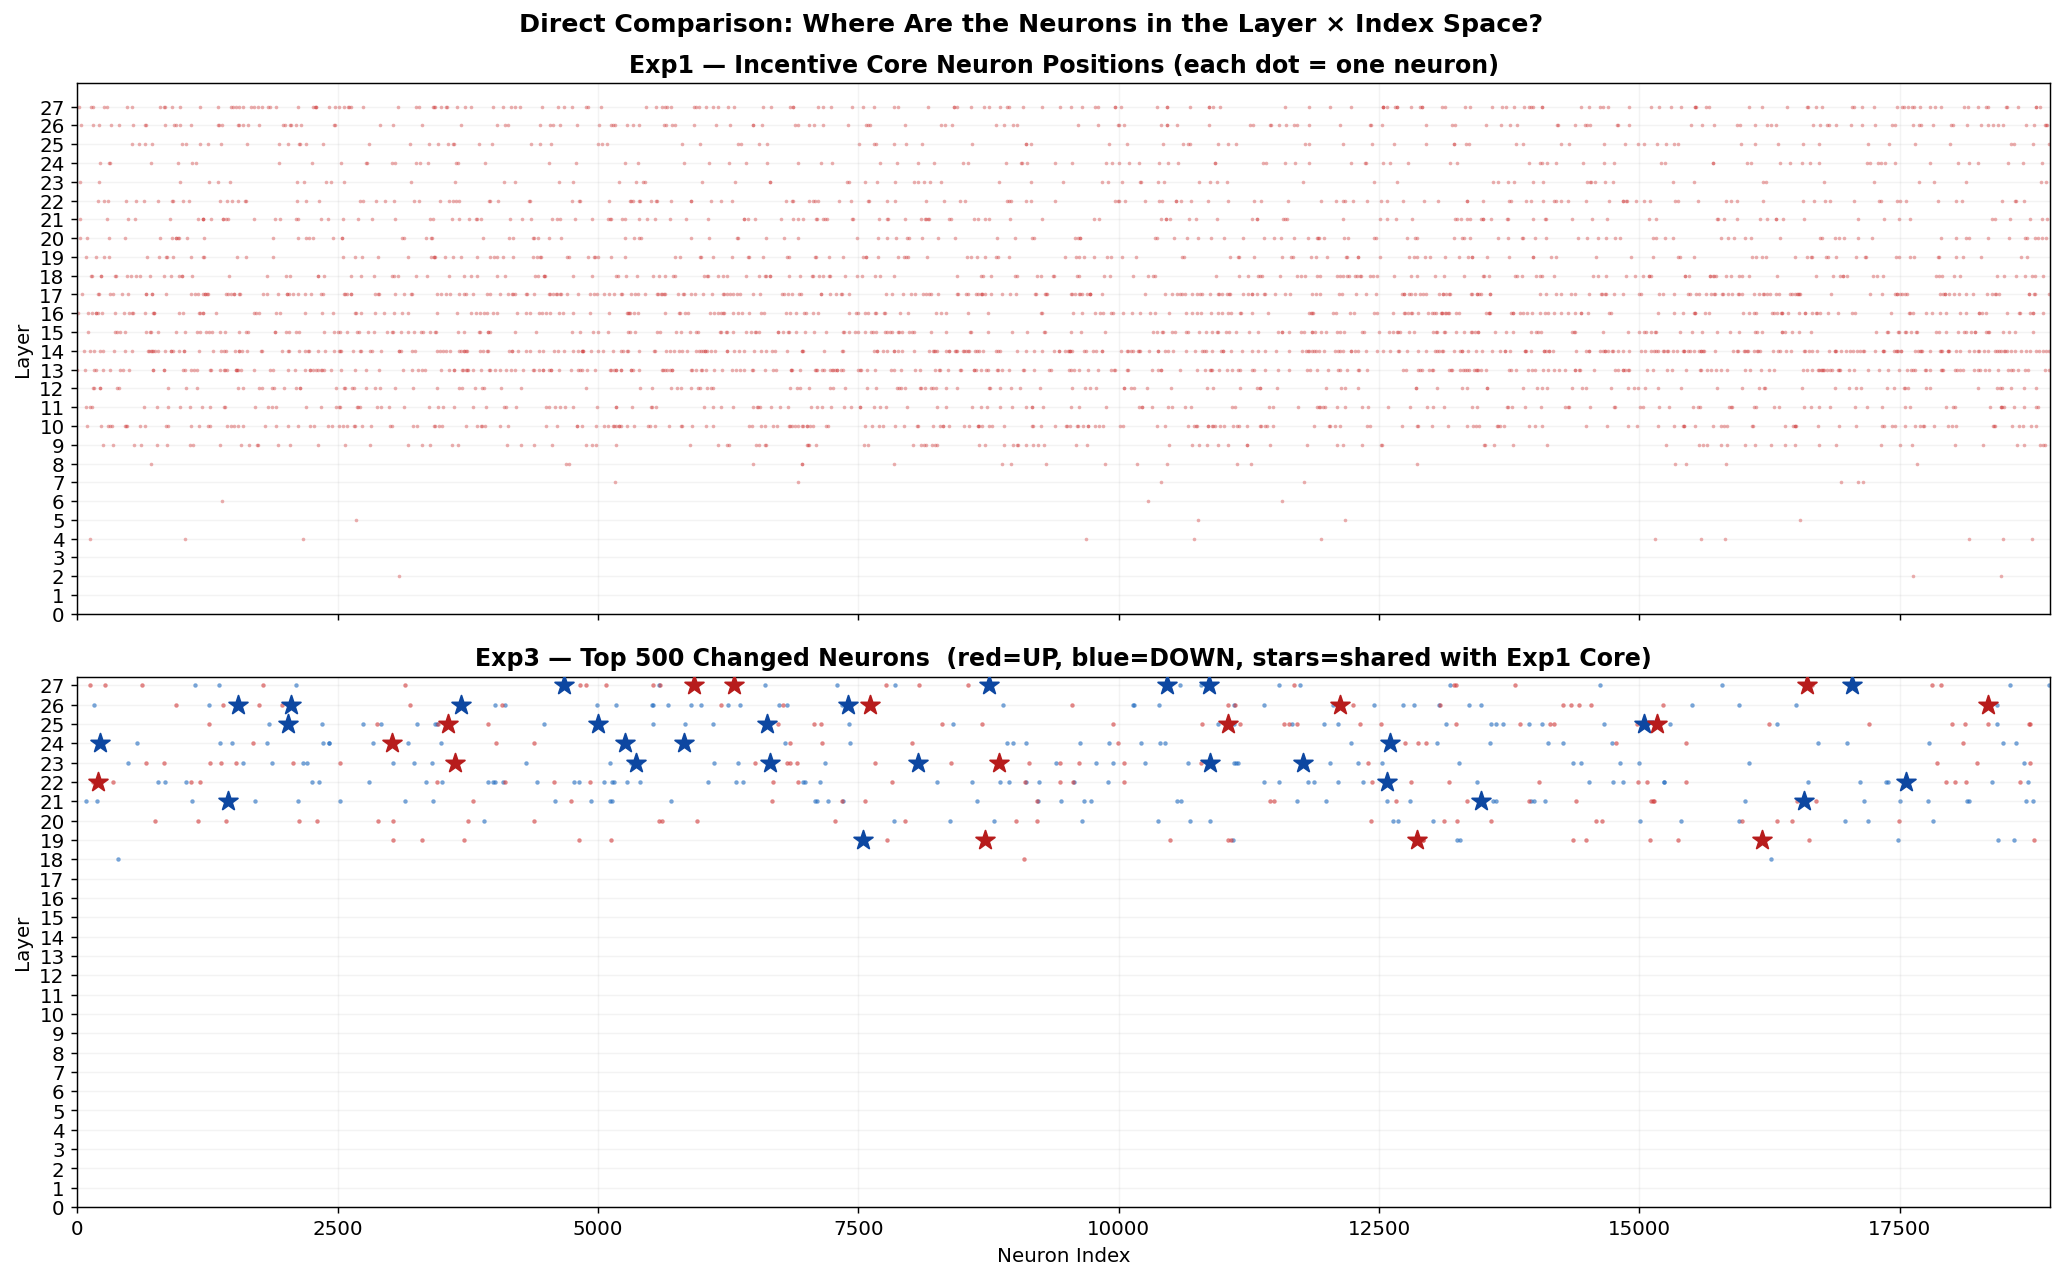

In [6]:
# For each layer that has shared neurons: show Exp1 core density vs Exp3 change magnitude
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# ── TOP: Exp1 core neuron density across neuron index, per layer (stacked) ──
ax = axes[0]
# Show as horizontal strip per layer: each neuron in core gets a tick mark
for l in range(N_LAYERS):
    core_in_layer = [n for (ll, n) in set_core if ll == l]
    if core_in_layer:
        ax.scatter(core_in_layer, [l]*len(core_in_layer),
                   c='#D32F2F', s=4, alpha=0.4, linewidths=0)

ax.set_ylabel('Layer')
ax.set_yticks(range(N_LAYERS))
ax.set_title('Exp1 — Incentive Core Neuron Positions (each dot = one neuron)', fontweight='bold')
ax.set_xlim(0, N_NEURONS)
ax.grid(alpha=0.15)

# ── BOTTOM: Exp3 delta heatmap across neuron index per layer ──
ax = axes[1]
for l in range(N_LAYERS):
    exp3_in_layer_down = [n for (ll, n) in set_exp3_down if ll == l]
    exp3_in_layer_up   = [n for (ll, n) in set_exp3_up   if ll == l]
    if exp3_in_layer_down:
        ax.scatter(exp3_in_layer_down, [l]*len(exp3_in_layer_down),
                   c='#1565C0', s=6, alpha=0.6, linewidths=0)
    if exp3_in_layer_up:
        ax.scatter(exp3_in_layer_up, [l]*len(exp3_in_layer_up),
                   c='#D32F2F', s=6, alpha=0.6, linewidths=0)

    # Star the shared ones
    shared_down = [n for (ll,n) in (set_exp3_down & set_core) if ll == l]
    shared_up   = [n for (ll,n) in (set_exp3_up   & set_core) if ll == l]
    if shared_down:
        ax.scatter(shared_down, [l]*len(shared_down),
                   c='#0D47A1', s=120, marker='*', zorder=5, label='Shared ↓' if l==min(ll for ll,_ in set_exp3_down & set_core) else '')
    if shared_up:
        ax.scatter(shared_up, [l]*len(shared_up),
                   c='#B71C1C', s=120, marker='*', zorder=5)

ax.set_xlabel('Neuron Index')
ax.set_ylabel('Layer')
ax.set_yticks(range(N_LAYERS))
ax.set_title('Exp3 — Top 500 Changed Neurons  (red=UP, blue=DOWN, stars=shared with Exp1 Core)', fontweight='bold')
ax.set_xlim(0, N_NEURONS)
ax.grid(alpha=0.15)

plt.suptitle('Direct Comparison: Where Are the Neurons in the Layer × Index Space?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_direct_comparison.png', bbox_inches='tight')
plt.show()

## Table — Exact Shared Neurons with Full Stats

In [7]:
rows = []
for rank, (l, n) in enumerate(zip(exp3_layers, exp3_neurs), 1):
    in_c = (l,n) in set_core
    in_m = (l,n) in set_money
    in_r = (l,n) in set_reward
    if in_c or in_m or in_r:
        rows.append({
            'exp3_rank':   rank,
            'layer':       int(l),
            'neuron':      int(n),
            'delta':       round(float(diff_signed[l,n]), 4),
            'effect_size': round(float(effect_size[l,n]),  4),
            'direction':   'UP' if diff_signed[l,n] > 0 else 'DOWN',
            'in_core':     in_c,
            'in_money':    in_m,
            'in_reward':   in_r,
        })

df_shared = pd.DataFrame(rows).sort_values('exp3_rank')

print(f'Total shared neurons (Exp3 top-500 ∩ any Exp1 set): {len(df_shared)}')
print(f'  In core   : {df_shared["in_core"].sum()}')
print(f'  DOWN      : {(df_shared["direction"]=="DOWN").sum()}')
print(f'  UP        : {(df_shared["direction"]=="UP").sum()}')
print()
print(df_shared.to_string(index=False))

df_shared.to_csv('shared_neurons_exp1_exp3.csv', index=False)
print('\nSaved → shared_neurons_exp1_exp3.csv')

Total shared neurons (Exp3 top-500 ∩ any Exp1 set): 83
  In core   : 44
  DOWN      : 55
  UP        : 28

 exp3_rank  layer  neuron   delta  effect_size direction  in_core  in_money  in_reward
        12     24    5826 -2.5621      -3.5821      DOWN     True      True       True
        13     23   11767 -2.5611      -4.2549      DOWN     True      True       True
        18     27    8753 -2.3717      -4.8689      DOWN     True      True       True
        22     25   18127  2.2085       2.5251        UP    False      True      False
        25     24    3020  2.0906       3.6999        UP     True      True       True
        30     21    1444 -2.0584      -5.5455      DOWN     True      True       True
        32     25    6726  2.0453       2.5369        UP    False      True      False
        36     26    7615  1.9946       3.0732        UP     True      True       True
        38     26    7400 -1.9810      -9.6015      DOWN     True      True       True
        51     26    20

Layers 18-27 only:
  Exp1 core   : 1363
  Exp1 money  : 2286
  Exp1 reward : 2095
  Exp3 top-500: 207 UP  |  293 DOWN


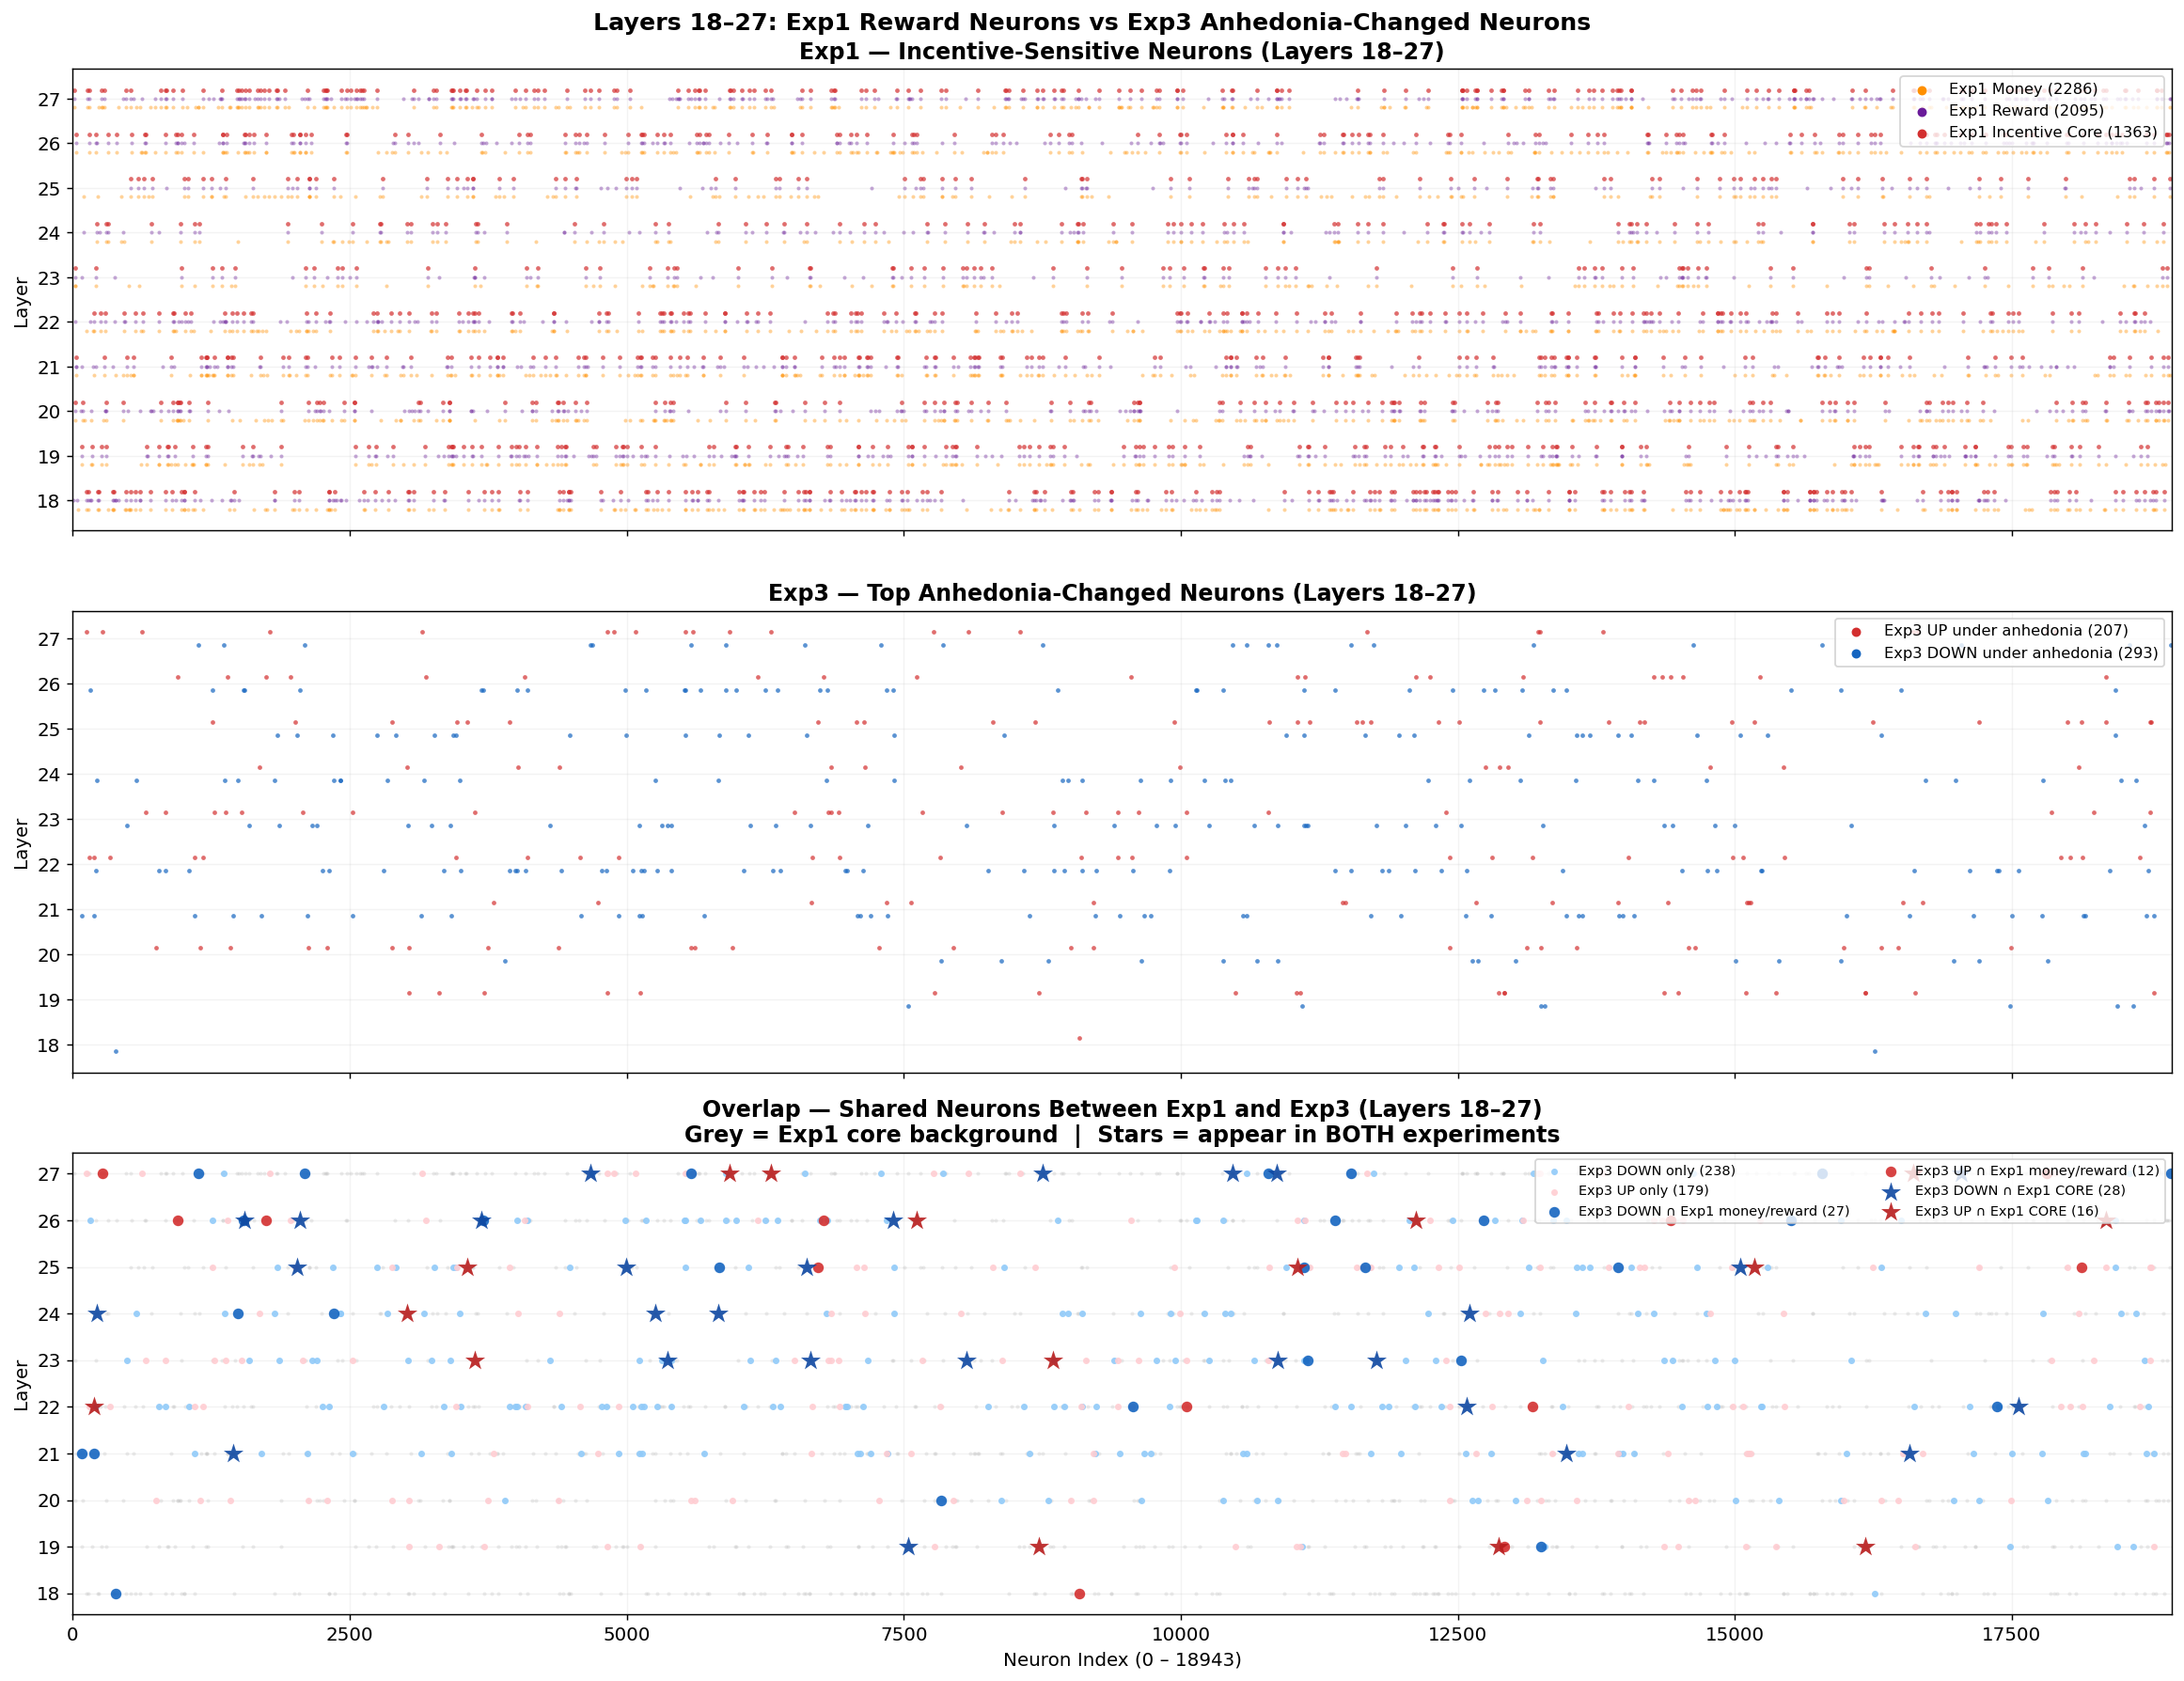


Shared neurons (layers 18-27, Exp3 top-500 ∩ any Exp1 set): 83
 layer  neuron   delta  effect_size direction  in_core  in_money  in_reward
    24    5826 -2.5621      -3.5821      DOWN     True      True       True
    23   11767 -2.5611      -4.2549      DOWN     True      True       True
    27    8753 -2.3717      -4.8689      DOWN     True      True       True
    25   18127  2.2085       2.5251        UP    False      True      False
    24    3020  2.0906       3.6999        UP     True      True       True
    21    1444 -2.0584      -5.5455      DOWN     True      True       True
    25    6726  2.0453       2.5369        UP    False      True      False
    26    7615  1.9946       3.0732        UP     True      True       True
    26    7400 -1.9810      -9.6015      DOWN     True      True       True
    26    2049 -1.8443      -6.3039      DOWN     True      True       True
    24    2355 -1.8002      -4.1323      DOWN    False      True      False
    25   15049 -1.7877  

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size']  = 11

N_NEURONS  = 18944
LAYERS     = list(range(18, 28))  # layers 18-27

# ── Load Exp1 ─────────────────────────────────────────────────────────────────
set_core   = {(r.layer, r.neuron) for _, r in df_core.iterrows()   if r.layer in LAYERS}
set_money  = {(r.layer, r.neuron) for _, r in df_money.iterrows()  if r.layer in LAYERS}
set_reward = {(r.layer, r.neuron) for _, r in df_reward.iterrows() if r.layer in LAYERS}

# ── Load Exp3 ─────────────────────────────────────────────────────────────────
neu_normal    = np.load('activations/activations_neurons_normal.npy')
neu_anhedonic = np.load('activations/activations_neurons_anhedonic.npy')

diff_signed = neu_anhedonic.mean(axis=0) - neu_normal.mean(axis=0)   # (28, 18944)
diff_abs    = np.abs(diff_signed)
pooled_std  = np.sqrt((neu_normal.std(axis=0)**2 + neu_anhedonic.std(axis=0)**2) / 2 + 1e-8)
effect_size = diff_signed / pooled_std

# Top-500 Exp3 neurons restricted to layers 18-27
layer_mask = np.zeros((28, N_NEURONS), dtype=bool)
for l in LAYERS:
    layer_mask[l, :] = True

masked_abs = diff_abs.copy()
masked_abs[~layer_mask] = 0

flat_idx    = np.argsort(masked_abs.flatten())[::-1][:500]
exp3_layers = flat_idx // N_NEURONS
exp3_neurs  = flat_idx %  N_NEURONS
# keep only those that actually had nonzero abs diff (i.e. are in layers 18-27)
valid       = masked_abs.flatten()[flat_idx] > 0
exp3_layers = exp3_layers[valid]
exp3_neurs  = exp3_neurs[valid]

exp3_deltas = diff_signed[exp3_layers, exp3_neurs]
set_exp3_up   = {(l, n) for l, n in zip(exp3_layers, exp3_neurs) if diff_signed[l, n] > 0}
set_exp3_down = {(l, n) for l, n in zip(exp3_layers, exp3_neurs) if diff_signed[l, n] < 0}
set_exp3      = set_exp3_up | set_exp3_down

print(f"Layers 18-27 only:")
print(f"  Exp1 core   : {len(set_core)}")
print(f"  Exp1 money  : {len(set_money)}")
print(f"  Exp1 reward : {len(set_reward)}")
print(f"  Exp3 top-500: {len(set_exp3_up)} UP  |  {len(set_exp3_down)} DOWN")

# ── Figure: 3 rows × 1 col ────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(18, 14), sharex=True)

# ── Row 1: Exp1 neuron positions per layer ────────────────────────────────────
ax = axes[0]
for l in LAYERS:
    core_n   = [n for (ll,n) in set_core   if ll == l]
    money_n  = [n for (ll,n) in set_money  if ll == l]
    reward_n = [n for (ll,n) in set_reward if ll == l]
    ax.scatter(money_n,  [l - 0.2]*len(money_n),  c='#FF8F00', s=5, alpha=0.4, linewidths=0)
    ax.scatter(reward_n, [l      ]*len(reward_n),  c='#6A1B9A', s=5, alpha=0.4, linewidths=0)
    ax.scatter(core_n,   [l + 0.2]*len(core_n),   c='#D32F2F', s=7, alpha=0.7, linewidths=0)

# Legend proxies
ax.scatter([], [], c='#FF8F00', s=20, label=f'Exp1 Money ({len(set_money)})')
ax.scatter([], [], c='#6A1B9A', s=20, label=f'Exp1 Reward ({len(set_reward)})')
ax.scatter([], [], c='#D32F2F', s=20, label=f'Exp1 Incentive Core ({len(set_core)})')
ax.set_yticks(LAYERS)
ax.set_ylabel('Layer')
ax.set_title('Exp1 — Incentive-Sensitive Neurons (Layers 18–27)', fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.15)

# ── Row 2: Exp3 changed neurons per layer ────────────────────────────────────
ax = axes[1]
for l in LAYERS:
    up_n   = [n for (ll,n) in set_exp3_up   if ll == l]
    down_n = [n for (ll,n) in set_exp3_down if ll == l]
    ax.scatter(up_n,   [l + 0.15]*len(up_n),   c='#D32F2F', s=7, alpha=0.7, linewidths=0)
    ax.scatter(down_n, [l - 0.15]*len(down_n), c='#1565C0', s=7, alpha=0.7, linewidths=0)

ax.scatter([], [], c='#D32F2F', s=20, label=f'Exp3 UP under anhedonia ({len(set_exp3_up)})')
ax.scatter([], [], c='#1565C0', s=20, label=f'Exp3 DOWN under anhedonia ({len(set_exp3_down)})')
ax.set_yticks(LAYERS)
ax.set_ylabel('Layer')
ax.set_title('Exp3 — Top Anhedonia-Changed Neurons (Layers 18–27)', fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.15)

# ── Row 3: Overlap — shared neurons highlighted ───────────────────────────────
ax = axes[2]

# Background: all Exp1 core (grey)
for l in LAYERS:
    core_n = [n for (ll,n) in set_core if ll == l]
    ax.scatter(core_n, [l]*len(core_n), c='#BDBDBD', s=5, alpha=0.3, linewidths=0)

# Overlap: in Exp3 AND in Exp1 sets
overlap_down_core   = set_exp3_down & set_core
overlap_up_core     = set_exp3_up   & set_core
overlap_down_any    = set_exp3_down & (set_money | set_reward) - set_core
overlap_up_any      = set_exp3_up   & (set_money | set_reward) - set_core
exp3_only_down      = set_exp3_down - set_core - set_money - set_reward
exp3_only_up        = set_exp3_up   - set_core - set_money - set_reward

for s, color, marker, size, label in [
    (exp3_only_down,    '#90CAF9', 'o', 15,  f'Exp3 DOWN only ({len(exp3_only_down)})'),
    (exp3_only_up,      '#FFCDD2', 'o', 15,  f'Exp3 UP only ({len(exp3_only_up)})'),
    (overlap_down_any,  '#1565C0', 'o', 40,  f'Exp3 DOWN ∩ Exp1 money/reward ({len(overlap_down_any)})'),
    (overlap_up_any,    '#D32F2F', 'o', 40,  f'Exp3 UP ∩ Exp1 money/reward ({len(overlap_up_any)})'),
    (overlap_down_core, '#0D47A1', '*', 150, f'Exp3 DOWN ∩ Exp1 CORE ({len(overlap_down_core)})'),
    (overlap_up_core,   '#B71C1C', '*', 150, f'Exp3 UP ∩ Exp1 CORE ({len(overlap_up_core)})'),
]:
    if s:
        ls, ns = zip(*s)
        ax.scatter(ns, ls, c=color, s=size, marker=marker, alpha=0.9,
                   label=label, zorder=4 if marker=='*' else 2, linewidths=0)

ax.set_yticks(LAYERS)
ax.set_ylabel('Layer')
ax.set_xlabel('Neuron Index (0 – 18943)')
ax.set_title('Overlap — Shared Neurons Between Exp1 and Exp3 (Layers 18–27)\n'
             'Grey = Exp1 core background  |  Stars = appear in BOTH experiments', fontweight='bold')
ax.legend(fontsize=8, loc='upper right', ncol=2)
ax.grid(alpha=0.15)
ax.set_xlim(0, N_NEURONS)

plt.suptitle('Layers 18–27: Exp1 Reward Neurons vs Exp3 Anhedonia-Changed Neurons',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_layers18_27_comparison.png', bbox_inches='tight')
plt.show()

# ── Print exact shared neuron table ──────────────────────────────────────────
rows = []
for l, n in sorted(set_exp3, key=lambda x: diff_abs[x[0], x[1]], reverse=True):
    in_c = (l,n) in set_core
    in_m = (l,n) in set_money
    in_r = (l,n) in set_reward
    if in_c or in_m or in_r:
        rows.append({
            'layer':       l,
            'neuron':      n,
            'delta':       round(float(diff_signed[l,n]), 4),
            'effect_size': round(float(effect_size[l,n]),  4),
            'direction':   'UP' if diff_signed[l,n] > 0 else 'DOWN',
            'in_core':     in_c,
            'in_money':    in_m,
            'in_reward':   in_r,
        })

df_shared = pd.DataFrame(rows)
print(f"\nShared neurons (layers 18-27, Exp3 top-500 ∩ any Exp1 set): {len(df_shared)}")
print(df_shared.to_string(index=False))
df_shared.to_csv('shared_neurons_layers18_27.csv', index=False)
print("\nSaved → shared_neurons_layers18_27.csv")


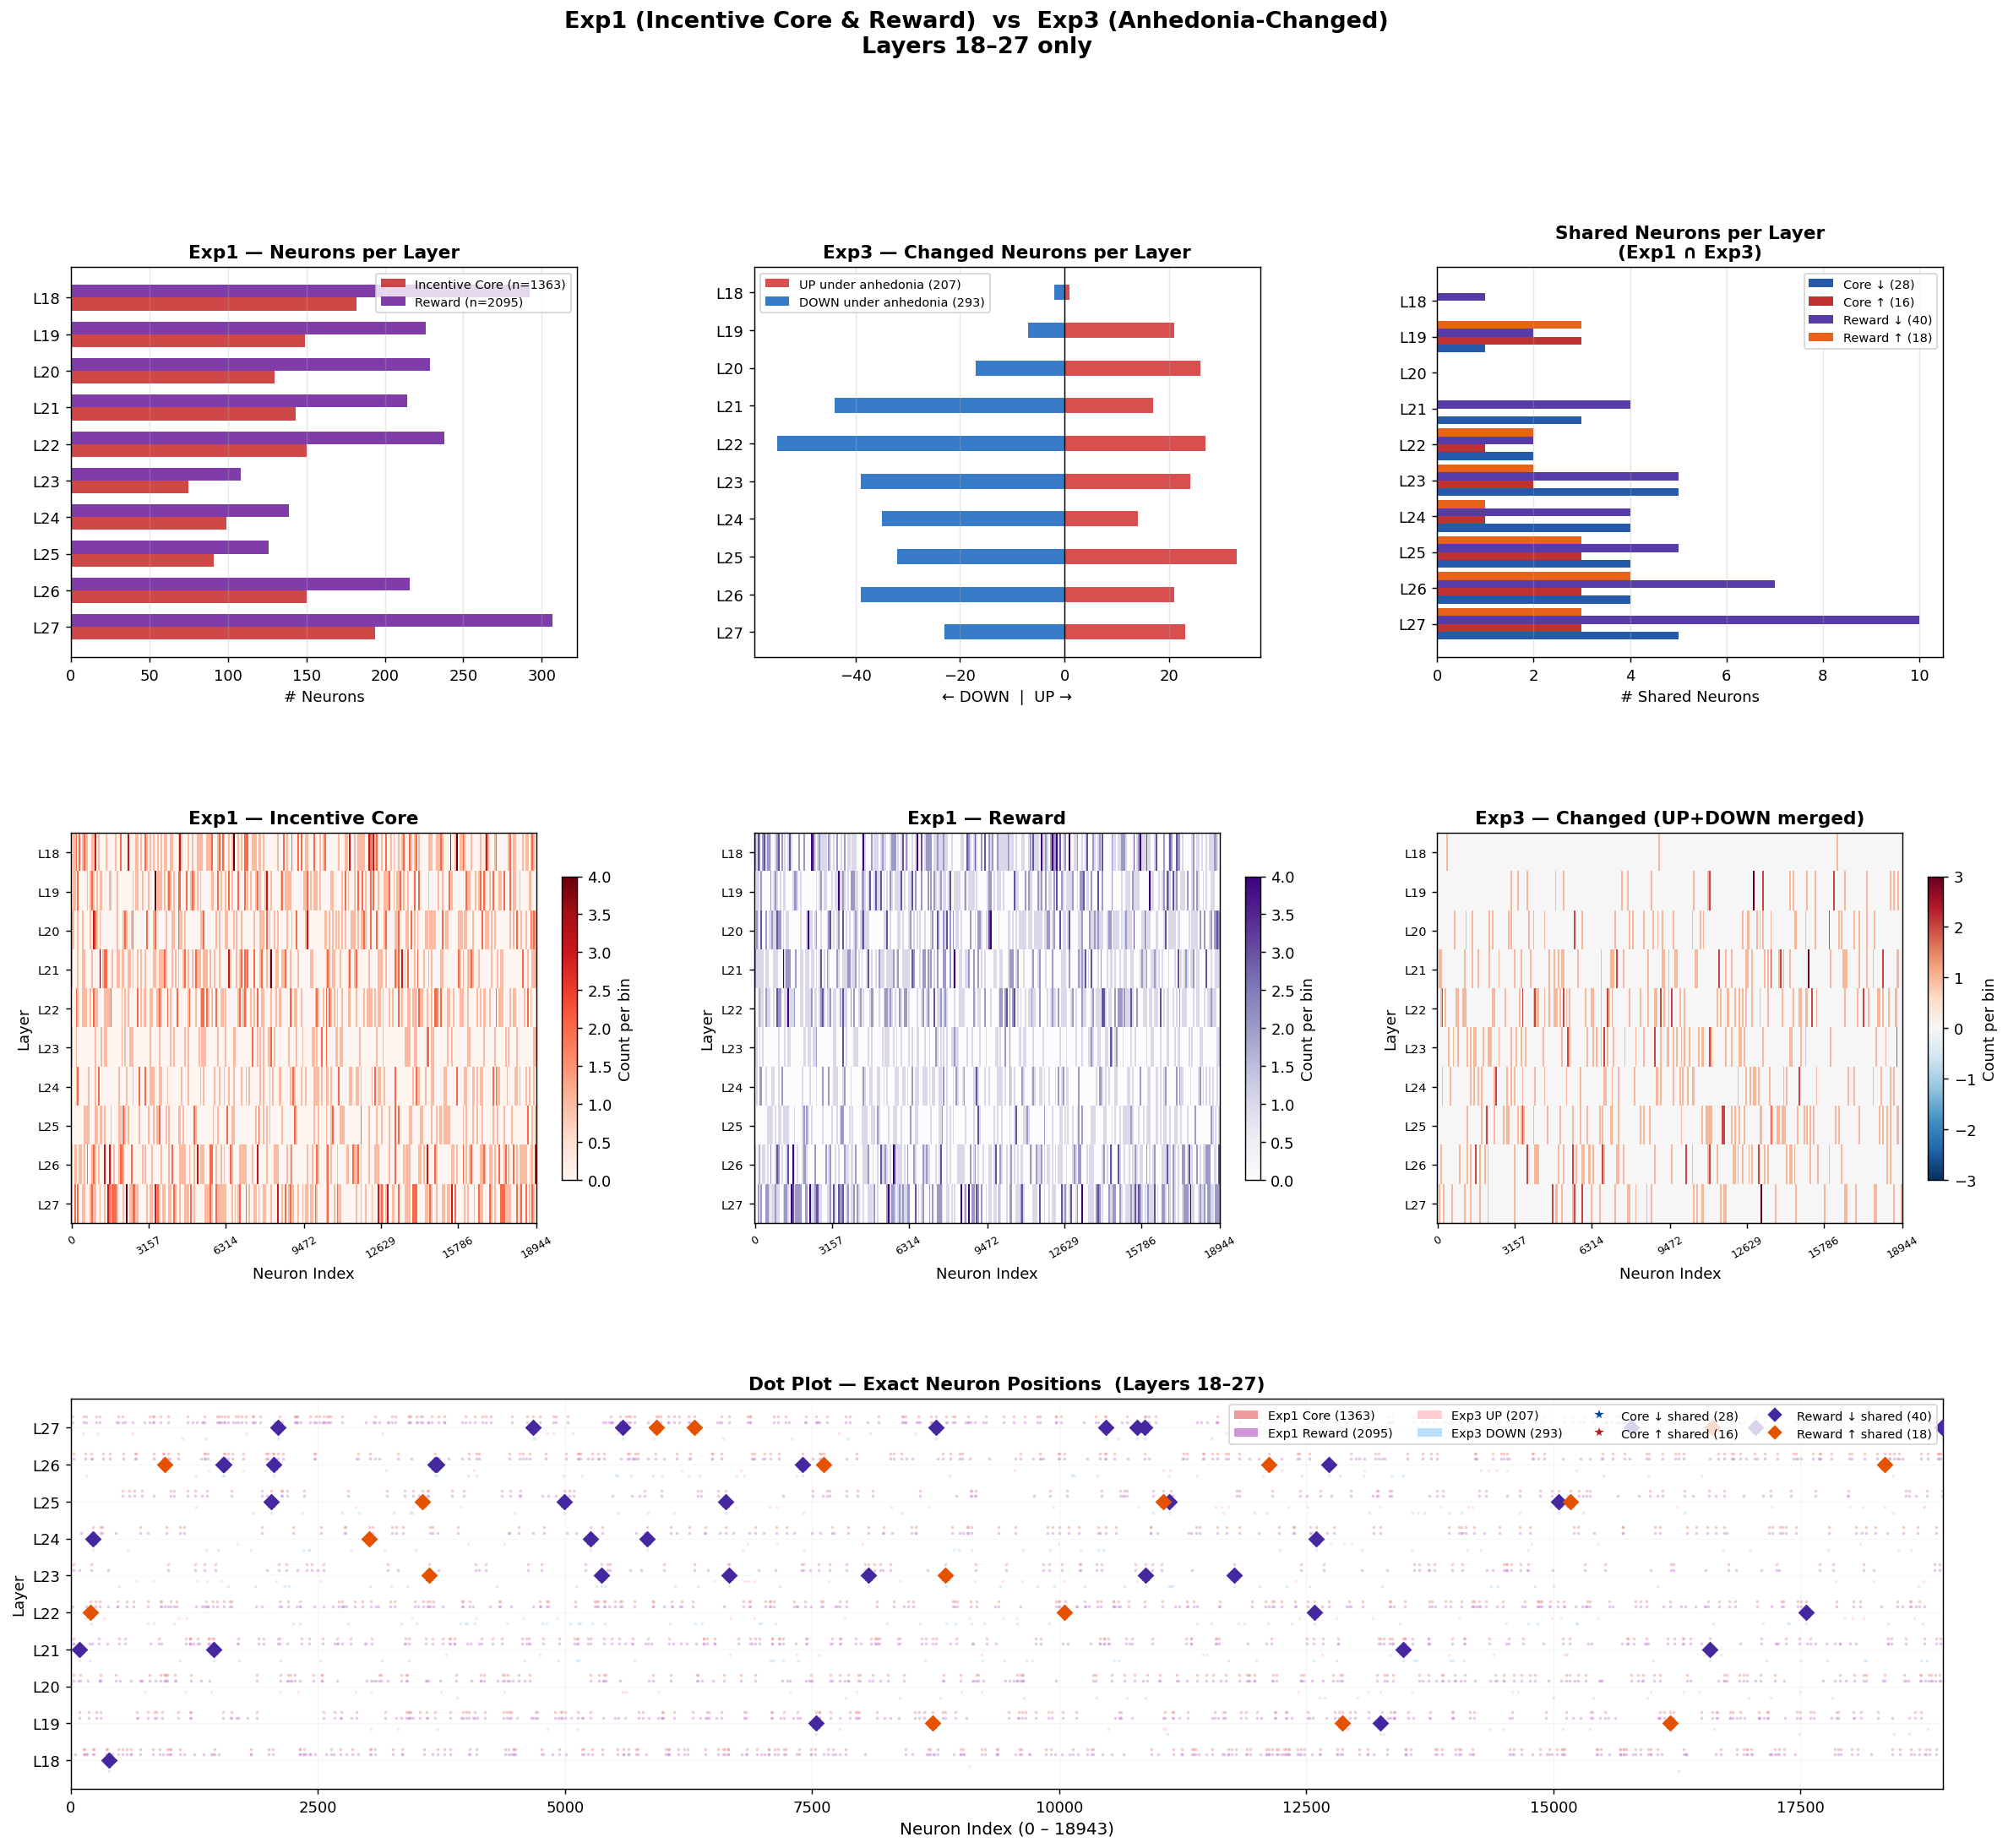

Shared neurons (layers 18-27): 58
 layer  neuron   delta  effect_size direction  in_core  in_reward
    24    5826 -2.5621      -3.5821      DOWN     True       True
    23   11767 -2.5611      -4.2549      DOWN     True       True
    27    8753 -2.3717      -4.8689      DOWN     True       True
    24    3020  2.0906       3.6999        UP     True       True
    21    1444 -2.0584      -5.5455      DOWN     True       True
    26    7615  1.9946       3.0732        UP     True       True
    26    7400 -1.9810      -9.6015      DOWN     True       True
    26    2049 -1.8443      -6.3039      DOWN     True       True
    25   15049 -1.7877      -2.4950      DOWN     True       True
    23    8069 -1.7700      -7.8269      DOWN     True       True
    22   17559 -1.7353     -11.7662      DOWN     True       True
    26    1546 -1.7264      -4.7392      DOWN     True       True
    27   17043 -1.6870      -5.2393      DOWN     True       True
    25    2025 -1.6360      -5.4420      D

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size']  = 10

N_NEURONS = 18944
LAYERS    = list(range(18, 28))

# ── Load ──────────────────────────────────────────────────────────────────────

neu_normal    = np.load('activations/activations_neurons_normal.npy')
neu_anhedonic = np.load('activations/activations_neurons_anhedonic.npy')

diff_signed = neu_anhedonic.mean(axis=0) - neu_normal.mean(axis=0)
diff_abs    = np.abs(diff_signed)
pooled_std  = np.sqrt((neu_normal.std(axis=0)**2 + neu_anhedonic.std(axis=0)**2) / 2 + 1e-8)
effect_size = diff_signed / pooled_std

# ── Filter to layers 18-27 ────────────────────────────────────────────────────
set_core   = {(r.layer, r.neuron) for _,r in df_core.iterrows()   if r.layer in LAYERS}
set_reward = {(r.layer, r.neuron) for _,r in df_reward.iterrows() if r.layer in LAYERS}

# Exp3 top-500 within layers 18-27 only
masked = diff_abs.copy()
masked[:18, :] = 0
masked[28:, :] = 0
flat_idx    = np.argsort(masked.flatten())[::-1][:500]
flat_idx    = flat_idx[masked.flatten()[flat_idx] > 0]
exp3_l      = flat_idx // N_NEURONS
exp3_n      = flat_idx %  N_NEURONS
set_exp3_up   = {(l,n) for l,n in zip(exp3_l, exp3_n) if diff_signed[l,n] > 0}
set_exp3_down = {(l,n) for l,n in zip(exp3_l, exp3_n) if diff_signed[l,n] < 0}
set_exp3      = set_exp3_up | set_exp3_down

# ── Shared neurons ────────────────────────────────────────────────────────────
shared_core_down   = sorted(set_exp3_down & set_core,   key=lambda x: diff_abs[x[0],x[1]], reverse=True)
shared_core_up     = sorted(set_exp3_up   & set_core,   key=lambda x: diff_abs[x[0],x[1]], reverse=True)
shared_reward_down = sorted(set_exp3_down & set_reward, key=lambda x: diff_abs[x[0],x[1]], reverse=True)
shared_reward_up   = sorted(set_exp3_up   & set_reward, key=lambda x: diff_abs[x[0],x[1]], reverse=True)

# ── Count per layer ───────────────────────────────────────────────────────────
def cpl(s): return [sum(1 for (ll,_) in s if ll==l) for l in LAYERS]

core_cpl         = cpl(set_core)
reward_cpl       = cpl(set_reward)
exp3_up_cpl      = cpl(set_exp3_up)
exp3_down_cpl    = cpl(set_exp3_down)
shared_cd_cpl    = cpl(set(shared_core_down))
shared_cu_cpl    = cpl(set(shared_core_up))
shared_rd_cpl    = cpl(set(shared_reward_down))
shared_ru_cpl    = cpl(set(shared_reward_up))

# ═════════════════════════════════════════════════════════════════════════════
# FIGURE
# ═════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(22, 18))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

y     = np.arange(len(LAYERS))
layer_labels = [f'L{l}' for l in LAYERS]

# ─────────────────────────────────────────────────────────────────────────────
# ROW 0: Bar charts — layer distributions
# ─────────────────────────────────────────────────────────────────────────────

# Col 0: Exp1 core + reward per layer
ax = fig.add_subplot(gs[0, 0])
w  = 0.35
ax.barh(y + w/2, core_cpl,   w, color='#C62828', alpha=0.85, label=f'Incentive Core (n={len(set_core)})')
ax.barh(y - w/2, reward_cpl, w, color='#6A1B9A', alpha=0.85, label=f'Reward (n={len(set_reward)})')
ax.set_yticks(y); ax.set_yticklabels(layer_labels)
ax.set_xlabel('# Neurons'); ax.set_title('Exp1 — Neurons per Layer', fontweight='bold')
ax.legend(fontsize=8); ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

# Col 1: Exp3 up/down per layer
ax = fig.add_subplot(gs[0, 1])
ax.barh(y,  exp3_up_cpl,   0.4, color='#D32F2F', alpha=0.85, label=f'UP under anhedonia ({len(set_exp3_up)})')
ax.barh(y, [-v for v in exp3_down_cpl], 0.4, color='#1565C0', alpha=0.85, label=f'DOWN under anhedonia ({len(set_exp3_down)})')
ax.axvline(0, color='black', lw=0.8)
ax.set_yticks(y); ax.set_yticklabels(layer_labels)
ax.set_xlabel('← DOWN  |  UP →'); ax.set_title('Exp3 — Changed Neurons per Layer', fontweight='bold')
ax.legend(fontsize=8); ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

# Col 2: Shared (overlap) per layer
ax = fig.add_subplot(gs[0, 2])
w  = 0.22
ax.barh(y + 1.5*w, shared_cd_cpl, w, color='#0D47A1', alpha=0.9, label=f'Core ↓ ({len(shared_core_down)})')
ax.barh(y + 0.5*w, shared_cu_cpl, w, color='#B71C1C', alpha=0.9, label=f'Core ↑ ({len(shared_core_up)})')
ax.barh(y - 0.5*w, shared_rd_cpl, w, color='#4527A0', alpha=0.9, label=f'Reward ↓ ({len(shared_reward_down)})')
ax.barh(y - 1.5*w, shared_ru_cpl, w, color='#E65100', alpha=0.9, label=f'Reward ↑ ({len(shared_reward_up)})')
ax.set_yticks(y); ax.set_yticklabels(layer_labels)
ax.set_xlabel('# Shared Neurons'); ax.set_title('Shared Neurons per Layer\n(Exp1 ∩ Exp3)', fontweight='bold')
ax.legend(fontsize=8); ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

# ─────────────────────────────────────────────────────────────────────────────
# ROW 1: Heatmaps — presence in layer × neuron index space
# ─────────────────────────────────────────────────────────────────────────────

def make_binary_matrix(neuron_set, layers=LAYERS, n_neurons=N_NEURONS):
    mat = np.zeros((len(layers), n_neurons), dtype=np.float32)
    for (l, n) in neuron_set:
        if l in layers:
            mat[layers.index(l), n] = 1.0
    return mat

mat_core   = make_binary_matrix(set_core)
mat_reward = make_binary_matrix(set_reward)
mat_exp3_up   = make_binary_matrix(set_exp3_up)
mat_exp3_down = make_binary_matrix(set_exp3_down)

# Smooth for visibility (pool into bins of 64 neurons)
BIN = 64
def bin_matrix(mat, bin_size=BIN):
    n_bins = mat.shape[1] // bin_size
    return mat[:, :n_bins*bin_size].reshape(mat.shape[0], n_bins, bin_size).sum(axis=2)

bc = bin_matrix(mat_core)
br = bin_matrix(mat_reward)
bu = bin_matrix(mat_exp3_up)
bd = bin_matrix(mat_exp3_down)
n_bins   = bc.shape[1]
bin_ticks = np.linspace(0, N_NEURONS, 7, dtype=int)
bin_tick_pos = (bin_ticks / BIN).astype(int)

for col, (mat, title, cmap) in enumerate([
    (bc,   'Exp1 — Incentive Core',          'Reds'),
    (br,   'Exp1 — Reward',                  'Purples'),
    (bu+bd,'Exp3 — Changed (UP+DOWN merged)', 'RdBu_r'),
]):
    ax = fig.add_subplot(gs[1, col])
    vmax = max(mat.max(), 1)
    im   = ax.imshow(mat, aspect='auto', cmap=cmap,
                     vmin=-vmax if cmap=='RdBu_r' else 0, vmax=vmax,
                     interpolation='nearest')
    ax.set_yticks(range(len(LAYERS))); ax.set_yticklabels(layer_labels, fontsize=8)
    ax.set_xticks(bin_tick_pos); ax.set_xticklabels(bin_ticks, fontsize=7, rotation=30)
    ax.set_xlabel('Neuron Index'); ax.set_ylabel('Layer')
    ax.set_title(title, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.03, label='Count per bin')

# ─────────────────────────────────────────────────────────────────────────────
# ROW 2: Dot plots — exact neuron positions (genome-browser style)
# ─────────────────────────────────────────────────────────────────────────────

ax = fig.add_subplot(gs[2, :])   # full width

for i, l in enumerate(LAYERS):
    # Exp1 core — red ticks at y = i + 0.3
    core_n   = [n for (ll,n) in set_core   if ll == l]
    reward_n = [n for (ll,n) in set_reward if ll == l]
    up_n     = [n for (ll,n) in set_exp3_up   if ll == l]
    down_n   = [n for (ll,n) in set_exp3_down if ll == l]
    sh_cu    = [n for (ll,n) in set(shared_core_up)     if ll == l]
    sh_cd    = [n for (ll,n) in set(shared_core_down)   if ll == l]
    sh_ru    = [n for (ll,n) in set(shared_reward_up)   if ll == l]
    sh_rd    = [n for (ll,n) in set(shared_reward_down) if ll == l]

    ax.scatter(core_n,   [i + 0.30]*len(core_n),   c='#EF9A9A', s=4,  alpha=0.5, linewidths=0)
    ax.scatter(reward_n, [i + 0.15]*len(reward_n), c='#CE93D8', s=4,  alpha=0.5, linewidths=0)
    ax.scatter(up_n,     [i - 0.15]*len(up_n),     c='#FFCDD2', s=4,  alpha=0.5, linewidths=0)
    ax.scatter(down_n,   [i - 0.30]*len(down_n),   c='#BBDEFB', s=4,  alpha=0.5, linewidths=0)
    # Shared — larger stars on top
    ax.scatter(sh_cd, [i]*len(sh_cd), c='#0D47A1', s=80,  marker='*', zorder=5, linewidths=0)
    ax.scatter(sh_cu, [i]*len(sh_cu), c='#B71C1C', s=80,  marker='*', zorder=5, linewidths=0)
    ax.scatter(sh_rd, [i]*len(sh_rd), c='#4527A0', s=60,  marker='D', zorder=5, linewidths=0)
    ax.scatter(sh_ru, [i]*len(sh_ru), c='#E65100', s=60,  marker='D', zorder=5, linewidths=0)

ax.set_yticks(range(len(LAYERS))); ax.set_yticklabels(layer_labels)
ax.set_xlabel('Neuron Index (0 – 18943)', fontsize=11)
ax.set_ylabel('Layer')
ax.set_xlim(0, N_NEURONS)
ax.set_title('Dot Plot — Exact Neuron Positions  (Layers 18–27)', fontweight='bold', fontsize=12)
ax.grid(alpha=0.1)

legend_elements = [
    Patch(facecolor='#EF9A9A', label=f'Exp1 Core ({len(set_core)})'),
    Patch(facecolor='#CE93D8', label=f'Exp1 Reward ({len(set_reward)})'),
    Patch(facecolor='#FFCDD2', label=f'Exp3 UP ({len(set_exp3_up)})'),
    Patch(facecolor='#BBDEFB', label=f'Exp3 DOWN ({len(set_exp3_down)})'),
    Line2D([0],[0], marker='*', color='w', markerfacecolor='#0D47A1', ms=10, label=f'Core ↓ shared ({len(shared_core_down)})'),
    Line2D([0],[0], marker='*', color='w', markerfacecolor='#B71C1C', ms=10, label=f'Core ↑ shared ({len(shared_core_up)})'),
    Line2D([0],[0], marker='D', color='w', markerfacecolor='#4527A0', ms=8,  label=f'Reward ↓ shared ({len(shared_reward_down)})'),
    Line2D([0],[0], marker='D', color='w', markerfacecolor='#E65100', ms=8,  label=f'Reward ↑ shared ({len(shared_reward_up)})'),
]
ax.legend(handles=legend_elements, fontsize=8, loc='upper right', ncol=4)

# ─────────────────────────────────────────────────────────────────────────────
fig.suptitle('Exp1 (Incentive Core & Reward)  vs  Exp3 (Anhedonia-Changed)\n'
             'Layers 18–27 only', fontsize=15, fontweight='bold', y=1.01)

plt.savefig('fig_exp1_exp3_full.png', bbox_inches='tight')
plt.show()

# ── Exact shared neuron table ─────────────────────────────────────────────────
rows = []
for l,n in sorted(set_exp3, key=lambda x: diff_abs[x[0],x[1]], reverse=True):
    in_c = (l,n) in set_core
    in_r = (l,n) in set_reward
    if in_c or in_r:
        rows.append({'layer': l, 'neuron': n,
                     'delta': round(float(diff_signed[l,n]),4),
                     'effect_size': round(float(effect_size[l,n]),4),
                     'direction': 'UP' if diff_signed[l,n]>0 else 'DOWN',
                     'in_core': in_c, 'in_reward': in_r})

df = pd.DataFrame(rows)
print(f"Shared neurons (layers 18-27): {len(df)}")
print(df.to_string(index=False))
df.to_csv('shared_neurons_layers18_27.csv', index=False)
print("Saved → shared_neurons_layers18_27.csv")
